In [1]:
import os
import warnings
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.util as cutil
import cmocean
import dask
from dask.distributed import Client, LocalCluster, Worker, progress
from dask.diagnostics import ProgressBar
pbar = ProgressBar()
pbar.register()
#from dask_jobqueue import SLURMCluster
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xesmf as xe
from load_SAIdata import Cases
%matplotlib inline

In [2]:
NAME = 'SSTanom'
ds = xr.open_dataset('../data/SST.nc')
with xr.open_dataset('../data/landmask.f02_t12.nc') as dset:
    ds['mask'] = dset.KMT
ds['dpm'] = ('month', [31,28,31,30,31,30,31,31,30,31,30,31])
ds['gw'] = xr.open_dataset('../data/gw.nc').gw
SSTmean = ds.SST.weighted(ds.gw).mean(('lat','lon'))
ds[NAME] = ds.SST - SSTmean

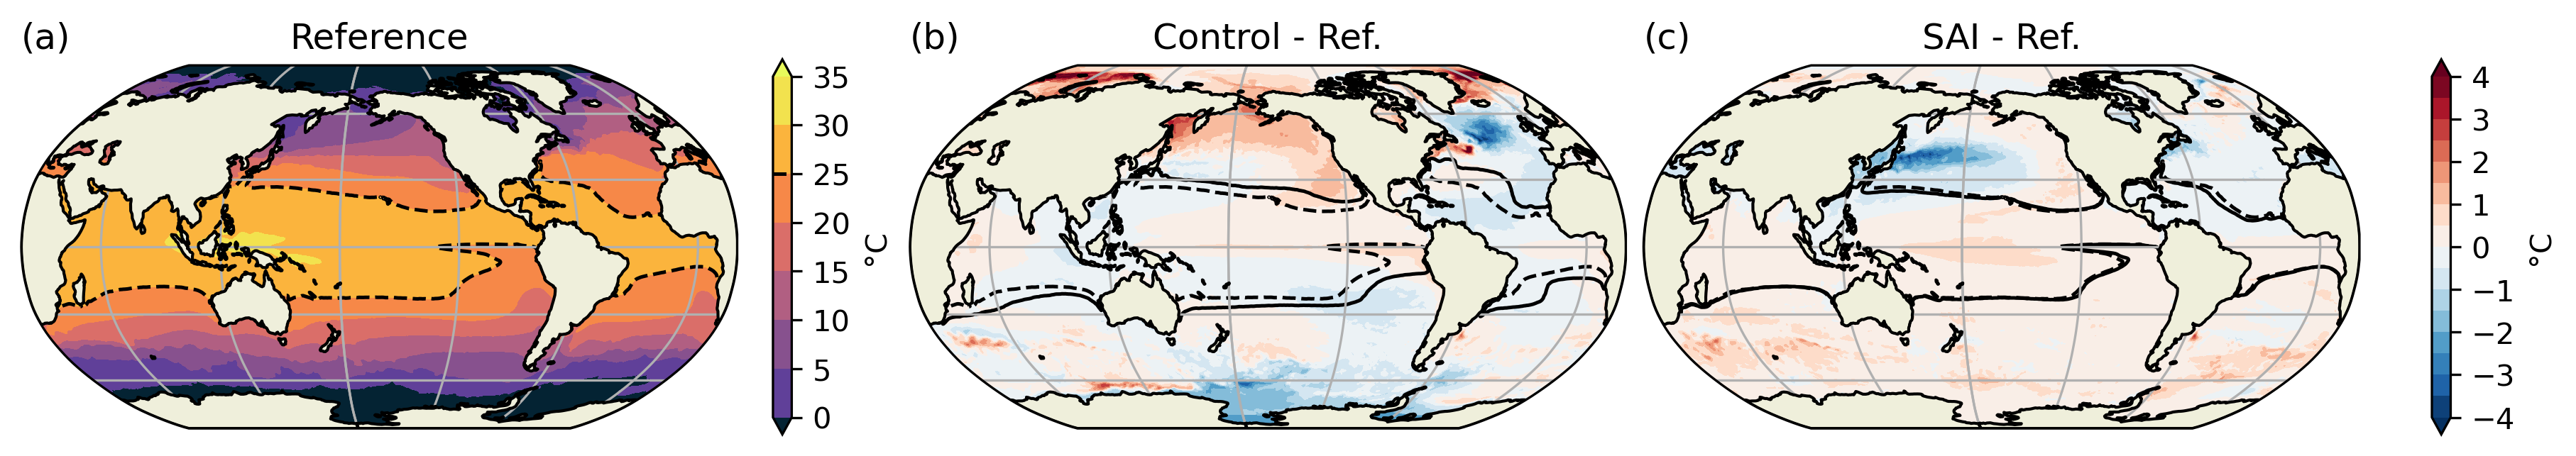

In [5]:
lats, lons = xr.broadcast(ds.lat, ds.lon)
kwargs = dict(transform=ccrs.PlateCarree(), transform_first=True)

# for data, title in zip((SST.mean('month', keep_attrs=True), SST.sel(month=10), SST.sel(month=4)), ['annual','october','april']):
dataref = ds.SST.weighted(ds.dpm).mean('month')
data = ds[NAME].weighted(ds.dpm).mean('month')

fig,axs = plt.subplots(1,3, dpi=300, figsize=(12,4), layout='constrained', subplot_kw={'projection':ccrs.Robinson(central_longitude=200)})

ax=axs[0]
pcm = ax.contourf(lons, lats, dataref.sel(exp='ref'), levels=np.arange(0,36,5), extend='both', vmin=-10, cmap='cmo.thermal', **kwargs)
pcc = ax.contour(lons, lats, dataref.sel(exp='ref'), levels=[25], colors='k', linewidths=1.2, linestyles='--', **kwargs)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pcm.set_rasterized(True)
    
cb = fig.colorbar(pcm, ax=axs[0], shrink=0.45, orientation='vertical')
cb.ax.axhline(25, lw=1.2, ls='--', c='k')
cb.ax.set_ylabel('°C')
ax.set_title('Reference')
ax.set_title('(a)', loc='left')

ax = axs[1]
ddata = data.sel(exp='cnt') - data.sel(exp='ref')
pcm = ax.contourf(lons, lats, ddata, levels=np.arange(-4,4.1,0.5), extend='both', cmap='RdBu_r', **kwargs)
pcc1 = ax.contour(lons, lats, dataref.sel(exp='ref'), levels=[25], colors='k', linewidths=1.2, linestyles='--', **kwargs)
pcc2 = ax.contour(lons, lats, dataref.sel(exp='cnt'), levels=[25], colors='k', linewidths=1.2, linestyles='-', **kwargs)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pcm.set_rasterized(True)
ax.set_title('Control - Ref.')
ax.set_title('(b)', loc='left')

ax = axs[2]
ddata = data.sel(exp='sai') - data.sel(exp='ref')
pcm = ax.contourf(lons, lats, ddata, levels=np.arange(-4,4.1,0.5), extend='both', cmap='RdBu_r', **kwargs)
pcc1 = ax.contour(lons, lats, dataref.sel(exp='ref'), levels=[25], colors='k', linewidths=1.2, linestyles='--', **kwargs)
pcc2 = ax.contour(lons, lats, dataref.sel(exp='sai'), levels=[25], colors='k', linewidths=1.2, linestyles='-', **kwargs)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pcm.set_rasterized(True)
ax.set_title('SAI - Ref.')
ax.set_title('(c)', loc='left')

cb = fig.colorbar(pcm, ax=axs[1:], shrink=0.45, orientation='vertical')
cb.ax.set_ylabel('°C')

for ax in axs.flatten():
    ax.gridlines()
    ax.add_feature(cfeature.LAND, zorder=2, edgecolor='black')

#fig.suptitle('annual mean SST', y=0.9)
fig.savefig(f'../figures/{NAME}.annualmean.pdf', dpi=300, bbox_inches='tight', transparent=True)


/scratch-local/55013/ipykernel_2169993/3024692775.py:12: UserWarning: Rasterization of '<cartopy.mpl.contour.GeoContourSet object at 0x14524fd0bb00>' will be ignored
  pcm.set_rasterized(True)


cnt-ref 330.6593933105469


/scratch-local/55013/ipykernel_2169993/3024692775.py:24: UserWarning: Rasterization of '<cartopy.mpl.contour.GeoContourSet object at 0x145250d4a090>' will be ignored
  pcm.set_rasterized(True)


sai-ref -148.5986785888672 79.80299377441406


/scratch-local/55013/ipykernel_2169993/3024692775.py:35: UserWarning: Rasterization of '<cartopy.mpl.contour.GeoContourSet object at 0x14524fca6870>' will be ignored
  pcm.set_rasterized(True)


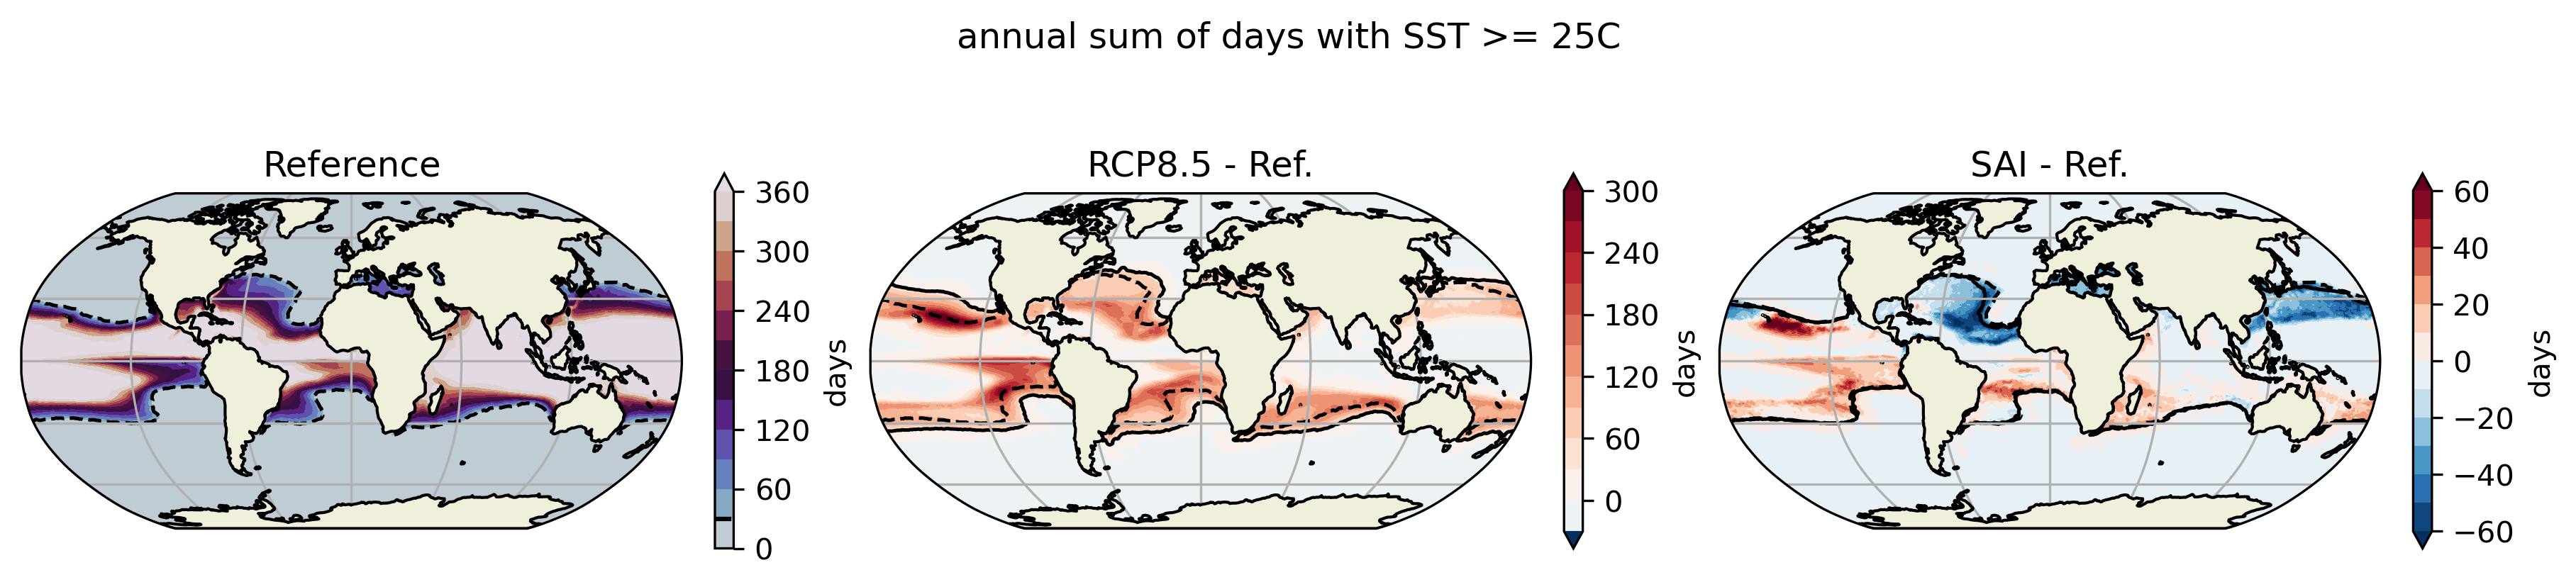

In [5]:
lats, lons = xr.broadcast(ds.lat, ds.lon)
kwargs = dict(transform=ccrs.PlateCarree(), transform_first=True)

# for data, title in zip((SST.mean('month', keep_attrs=True), SST.sel(month=10), SST.sel(month=4)), ['annual','october','april']):
data = ds.SSTdays.sum('month')

fig,axs = plt.subplots(1,3, dpi=300, figsize=(12,4), layout='constrained', subplot_kw={'projection':ccrs.Robinson()})

ax=axs[0]
ax.set_title('Reference')
pcm = ax.contourf(lons, lats, data.sel(exp='ref'), levels=np.arange(0,366,30), extend='max', vmin=-10, cmap='twilight', **kwargs)
pcm.set_rasterized(True)
ax.contour(lons, lats, data.sel(exp='ref'), levels=[30], colors='k', linewidths=1.2, linestyles='--', **kwargs)
cb = fig.colorbar(pcm, ax=axs[0], shrink=0.45, orientation='vertical')
cb.ax.set_ylabel('days')
cb.ax.axhline(30, c='k', ls='--')


ax = axs[1]
ax.set_title('RCP8.5 - Ref.')
ddata = data.sel(exp='cnt') - data.sel(exp='ref')
print('cnt-ref',ddata.max().item())
pcm = ax.contourf(lons, lats, ddata, levels=np.arange(-30,301,30), vmin=-300, extend='both', cmap='RdBu_r', **kwargs)
pcm.set_rasterized(True)
ax.contour(lons, lats, data.sel(exp='ref'), levels=[30], colors='k', linewidths=1.2, linestyles='--', **kwargs)
ax.contour(lons, lats, data.sel(exp='cnt'), levels=[30], colors='k', linewidths=1.2, linestyles='-', **kwargs)
cb = fig.colorbar(pcm, ax=axs[1], shrink=0.45, orientation='vertical')
cb.ax.set_ylabel('days')

ax = axs[2]
ax.set_title('SAI - Ref.')
ddata = data.sel(exp='sai') - data.sel(exp='ref')
print('sai-ref',ddata.min().item(),ddata.max().item())
pcm = ax.contourf(lons, lats, ddata, levels=np.arange(-60,60.1,10), extend='both', cmap='RdBu_r', **kwargs)
pcm.set_rasterized(True)
ax.contour(lons, lats, data.sel(exp='ref'), levels=[30], colors='k', linewidths=1.2, linestyles='--', **kwargs)
ax.contour(lons, lats, data.sel(exp='sai'), levels=[30], colors='k', linewidths=1.2, linestyles='-', **kwargs)
cb = fig.colorbar(pcm, ax=axs[2], shrink=0.45, orientation='vertical')
cb.ax.set_ylabel('days')

for ax in axs.flatten():
    ax.gridlines()
    ax.add_feature(cfeature.LAND, zorder=2, edgecolor='black')

fig.suptitle('annual sum of days with SST >= 25C', y=0.9)
fig.savefig('../figures/SST.highdays.annualsum.pdf', bbox_inches='tight', transparent=True)


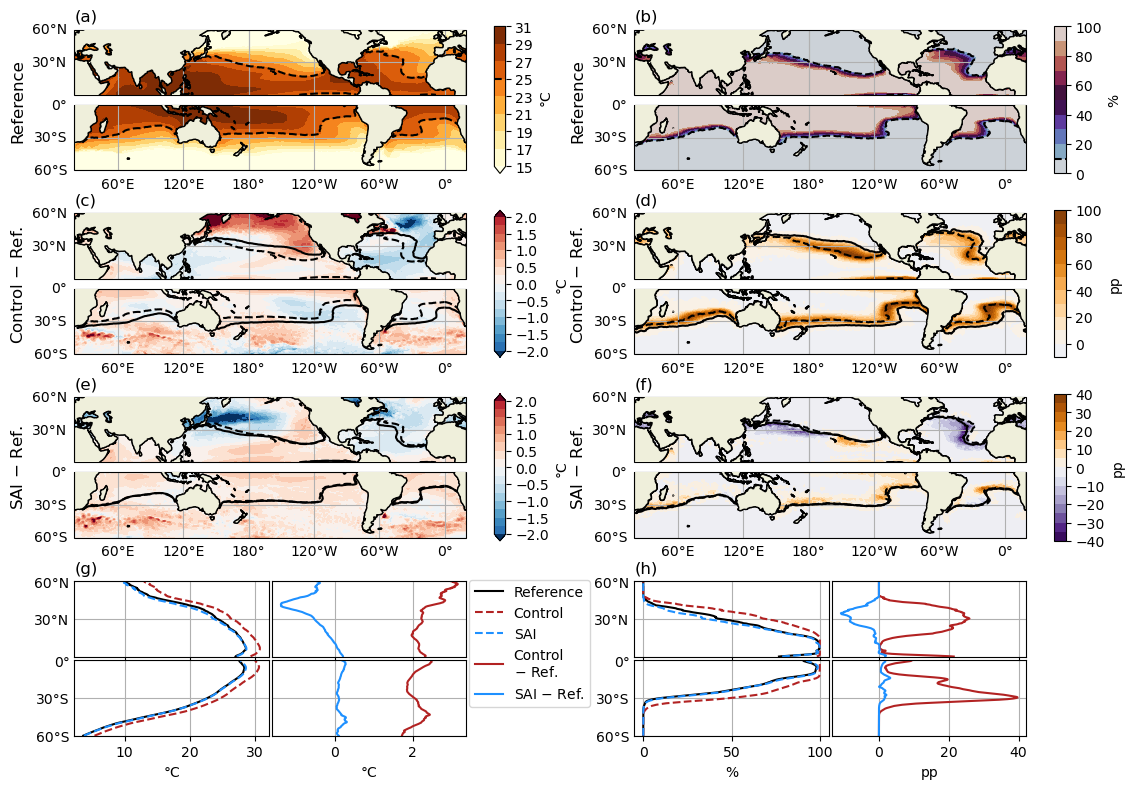

In [7]:
SST_NH = ds.SST.sel(month=[6,7,8,9,10], lat=slice(0,60)).weighted(ds.dpm).mean('month')
SST_SH = ds.SST.sel(month=[1,2,3,4,5], lat=slice(-60,0)).weighted(ds.dpm).mean('month')
SSTanom_NH = ds[NAME].sel(month=[6,7,8,9,10], lat=slice(0,60)).weighted(ds.dpm).mean('month')
SSTanom_SH = ds[NAME].sel(month=[1,2,3,4,5], lat=slice(-60,0)).weighted(ds.dpm).mean('month')
days_NH = ds.SSTdays.sel(month=[6,7,8,9,10], lat=slice(0,60)).sum('month') / ds.dpm.sel(month=[6,7,8,9,10]).sum('month') * 100
days_SH = ds.SSTdays.sel(month=[1,2,3,4,5], lat=slice(-60,0)).sum('month') / ds.dpm.sel(month=[1,2,3,4,5]).sum('month') * 100

cfdata = {
    'a': [SST_NH.sel(exp='ref'), SST_SH.sel(exp='ref')],
    'b': [days_NH.sel(exp='ref'), days_SH.sel(exp='ref')],
    'c': [SSTanom_NH.sel(exp='cnt')-SSTanom_NH.sel(exp='ref'),
          SSTanom_SH.sel(exp='cnt')-SSTanom_SH.sel(exp='ref')],
    'd': [days_NH.sel(exp='cnt')-days_NH.sel(exp='ref'),
          days_SH.sel(exp='cnt')-days_SH.sel(exp='ref')],
    'e': [SSTanom_NH.sel(exp='sai')-SSTanom_NH.sel(exp='ref'),
          SSTanom_SH.sel(exp='sai')-SSTanom_SH.sel(exp='ref')],
    'f': [days_NH.sel(exp='sai')-days_NH.sel(exp='ref'),
          days_SH.sel(exp='sai')-days_SH.sel(exp='ref')],
}

cfkwargs = {
    'a': dict(transform=ccrs.PlateCarree(), levels=np.linspace(15,31,9), extend='min',     cmap='YlOrBr'),
    'b': dict(transform=ccrs.PlateCarree(), levels=np.linspace(0,100,11), extend='neither', cmap='twilight'),
    'c': dict(transform=ccrs.PlateCarree(), levels=np.linspace(-2,2,17),  extend='both',    cmap='RdBu_r', vmin=-2.5, vmax=2.5),
    'd': dict(transform=ccrs.PlateCarree(), levels=np.linspace(-10,100,12),extend='neither', cmap='PuOr_r', vmin=-100, vmax=100),
    'e': dict(transform=ccrs.PlateCarree(), levels=np.linspace(-2,2,17),  extend='both', cmap='RdBu_r', vmin=-2.5, vmax=2.5),
    'f': dict(transform=ccrs.PlateCarree(), levels=np.linspace(-40,40,17),extend='neither', cmap='PuOr_r', vmin=-40, vmax=40),
}

cbkwargs = {'a': dict(label='°C'), 'b': dict(label='%'), 'c': dict(label='°C'),
    'd': dict(label='pp'), 'e': dict(label='°C'),'f': dict(label='pp')}

supy = {'a': 'Reference', 'b': 'Reference', 'c': 'Control $-$ Ref.',
        'd': 'Control $-$ Ref.', 'e': 'SAI $-$ Ref.', 'f': 'SAI $-$ Ref.'}

fig = plt.figure(figsize=(14*0.8, 0.6125*14*0.9))
subfigs = fig.subfigures(2, 1, hspace=0.0, height_ratios=[3, 1.2])
mapfigs = subfigs[0].subfigures(3,2,hspace=0, wspace=0)
zmfigs = subfigs[1].subfigures(1,2,wspace=0)

for i,mfig, in zip('abcdef', mapfigs.flatten()):
    axt, axb = mfig.subplots(2,1, sharex=True, subplot_kw={'projection':ccrs.PlateCarree(central_longitude=200)})
    cft = axt.contourf(cfdata[i][0].lon, cfdata[i][0].lat, cfdata[i][0], **cfkwargs[i])
    cfb = axb.contourf(cfdata[i][1].lon, cfdata[i][1].lat, cfdata[i][1], **cfkwargs[i])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        cft.set_rasterized(True)
        cfb.set_rasterized(True)
    for ax in (axt, axb):
        ax.coastlines()
        ax.add_feature(cfeature.LAND, zorder=3, edgecolor='k')
        ax.set_title('')
        ax.set_xlabel('')
        ax.set_ylabel('')
    axt.gridlines(ylocs=[0, 30, 60], draw_labels=['left'])
    axb.gridlines(ylocs=[0,-30,-60], draw_labels=['left','bottom'])
    axt.set_extent((20,380,0,60.0001), crs=ccrs.PlateCarree())
    axb.set_extent((20,380,-60.001,0.001), crs=ccrs.PlateCarree())
    mfig.subplots_adjust(left=0.125, right=0.825, top=0.9, bottom=0.1, hspace=0.05)
    cbtax = mfig.add_axes((0.875,0.1,0.02,0.8))
    mfig.colorbar(cft, cax=cbtax, **cbkwargs[i])
    axt.set_title(f'({i})', loc='left')
    mfig.supylabel(supy[i], x=0.01)

for v,var in enumerate([(SST_NH,SST_SH),(days_NH,days_SH)]):
    clevels = [[25], [10]][v]
    for m,(mfig,exp) in enumerate(zip(mapfigs[:,v],['ref','cnt','sai'])):
        if m == 0:
            mfig.axes[2].axhline(clevels, ls='--', c='k')
        for a,ax in enumerate(mfig.axes[:2]):
            cr = ax.contour(var[a].lon, var[a].lat, var[a].sel(exp='ref'), transform=ccrs.PlateCarree(), levels=clevels, linestyles=['--'], zorder=2, colors='k')
            if m >= 1:
                ce = ax.contour(var[a].lon, var[a].lat, var[a].sel(exp=exp), transform=ccrs.PlateCarree(), levels=clevels, linestyles=['-'], zorder=2, colors='k')


for z,zfig in enumerate(zmfigs.flatten()):
    axs = zfig.subplots(2,2, sharey='row', sharex='col')
    zfig.subplots_adjust(left=0.125, right=0.825, top=0.9, bottom=0.2, wspace=0.05/3)
    for ax in axs[0,:]:
        ax.set_ylim([0,60])
        ax.yaxis.set_tick_params(length=0)
    for ax in axs[1,:]:
        ax.set_ylim([-60,0])
        ax.yaxis.set_tick_params(length=0)
    axs[0,0].set_yticks([30,60], labels=['30°N','60°N'])
    axs[1,0].set_yticks([-60,-30,0], labels=['60°S','30°S','0°'])
    
for z,zfig in enumerate(zmfigs.flatten()):
    zfig.axes[0].set_title(f'({"gh"[z]})', loc='left')
    data_NH = [SST_NH.where(ds.mask<0.1), days_NH.where(ds.mask<0.1)][z]
    data_SH = [SST_SH.where(ds.mask<0.1), days_SH.where(ds.mask<0.1)][z]
    data_NH.sel(exp='ref').mean('lon').plot(ax=zfig.axes[0], y='lat', c='k', label='Reference')
    data_NH.sel(exp='cnt').mean('lon').plot(ax=zfig.axes[0], y='lat', c='firebrick', ls='--', label='Control')
    data_NH.sel(exp='sai').mean('lon').plot(ax=zfig.axes[0], y='lat', c='dodgerblue', ls='--', label='SAI')
    
    (data_NH.sel(exp='cnt').mean('lon')
     -data_NH.sel(exp='ref').mean('lon')).plot(ax=zfig.axes[1], y='lat', c='firebrick', label='Control\n$-$ Ref.')
    (data_NH.sel(exp='sai').mean('lon')
     -data_NH.sel(exp='ref').mean('lon')).plot(ax=zfig.axes[1], y='lat', c='dodgerblue', label='SAI $-$ Ref.')
    
    data_SH.sel(exp='ref').mean('lon').plot(ax=zfig.axes[2], y='lat', c='k', label='Reference')
    data_SH.sel(exp='cnt').mean('lon').plot(ax=zfig.axes[2], y='lat', c='firebrick', ls='--', label='Control')
    data_SH.sel(exp='sai').mean('lon').plot(ax=zfig.axes[2], y='lat', c='dodgerblue', ls='--', label='SAI')
    
    (data_SH.sel(exp='cnt').mean('lon')
     -data_SH.sel(exp='ref').mean('lon')).plot(ax=zfig.axes[3], y='lat', c='firebrick', label='Control\n$-$ Ref.')
    (data_SH.sel(exp='sai').mean('lon')
     -data_SH.sel(exp='ref').mean('lon')).plot(ax=zfig.axes[3], y='lat', c='dodgerblue', label='SAI $-$ Ref.')

han1, lab1 = zmfigs[0].axes[0].get_legend_handles_labels()
han2, lab2 = zmfigs[0].axes[1].get_legend_handles_labels()
zmfigs[0].legend(han1+han2, lab1+lab2, loc=(0.83,0.33))



for zfig in zmfigs:
    # zfig.set_edgecolor('k')
    # zfig.set_linewidth(.01)
    for ax in zfig.axes:
        ax.yaxis.set_tick_params(length=0)
        ax.set_title('')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.grid()

zmfigs[0].axes[2].set_xlabel('°C')
zmfigs[0].axes[3].set_xlabel('°C')
zmfigs[1].axes[2].set_xlabel('%')
zmfigs[1].axes[3].set_xlabel('pp')

fig.savefig(f'../figures/{NAME}.TCseason.pdf', dpi=300, transparent=True, bbox_inches='tight')

In [21]:
cfdata['a'][1].min()

<xarray.DataArray 'SST' ()> Size: 8B
array(-1.86487451)
Coordinates:
    exp      <U3 12B 'ref'

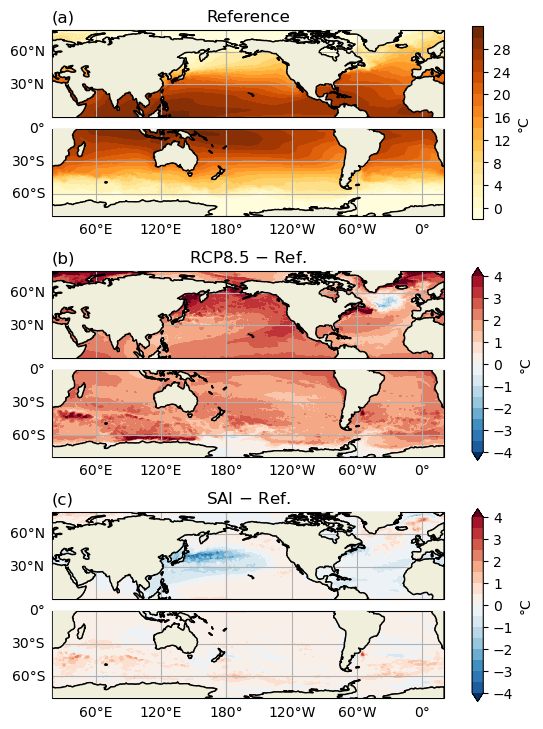

In [22]:
SST_NH = ds.SST.sel(month=[11,12,1,2,3], lat=slice(0,80)).weighted(ds.dpm).mean('month')
SST_SH = ds.SST.sel(month=[5,6,7,8,9], lat=slice(-80,0)).weighted(ds.dpm).mean('month')
#days_NH = ds.SSTdays.sel(month=[6,7,8,9,10], lat=slice(0,60)).sum('month') / ds.dpm.sel(month=[6,7,8,9,10]).sum('month') * 100
#days_SH = ds.SSTdays.sel(month=[1,2,3,4,5], lat=slice(-60,0)).sum('month') / ds.dpm.sel(month=[1,2,3,4,5]).sum('month') * 100

cfdata = {
    'a': [SST_NH.sel(exp='ref'), SST_SH.sel(exp='ref')],
    'b': [SST_NH.sel(exp='cnt')-SST_NH.sel(exp='ref'),
          SST_SH.sel(exp='cnt')-SST_SH.sel(exp='ref')],
    'c': [SST_NH.sel(exp='sai')-SST_NH.sel(exp='ref'),
          SST_SH.sel(exp='sai')-SST_SH.sel(exp='ref')],
}

cfkwargs = {
    'a': dict(transform=ccrs.PlateCarree(), levels=np.arange(-2,32.1,2), extend='neither',     cmap='YlOrBr'),
    'b': dict(transform=ccrs.PlateCarree(), levels=np.linspace(-4,4,17),  extend='both',    cmap='RdBu_r', vmin=-4.5, vmax=4.5),
    'c': dict(transform=ccrs.PlateCarree(), levels=np.linspace(-4,4,17),  extend='both', cmap='RdBu_r', vmin=-4.5, vmax=4.5),
}

cbkwargs = {'a': dict(label='°C', ticks=range(0,32,4)), 'b': dict(label='°C'), 'c': dict(label='°C')}

supy = {'a': 'Reference', 'b': 'RCP8.5 $-$ Ref.','c': 'SAI $-$ Ref.'}

fig = plt.figure(figsize=(14*0.8*0.5, 0.6125*14*0.9*0.75*1.25))
#subfigs = fig.subfigures(2, 1, hspace=0.0, height_ratios=[3, 1.2])
#mapfigs = subfigs[0].subfigures(3,2,hspace=0, wspace=0)
mapfigs = fig.subfigures(3,1,hspace=0, wspace=0)
#zmfigs = subfigs[1].subfigures(1,2,wspace=0)

for i,mfig, in zip('abc', mapfigs.flatten()):
    axt, axb = mfig.subplots(2,1, sharex=True, subplot_kw={'projection':ccrs.PlateCarree(central_longitude=200)})
    cft = axt.contourf(cfdata[i][0].lon, cfdata[i][0].lat, cfdata[i][0], **cfkwargs[i])
    cfb = axb.contourf(cfdata[i][1].lon, cfdata[i][1].lat, cfdata[i][1], **cfkwargs[i])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        cft.set_rasterized(True)
        cfb.set_rasterized(True)
    for ax in (axt, axb):
        ax.coastlines()
        ax.add_feature(cfeature.LAND, zorder=3, edgecolor='k')
        ax.set_title('')
        ax.set_xlabel('')
        ax.set_ylabel('')
    axt.gridlines(ylocs=[0, 30, 60], draw_labels=['left'])
    axb.gridlines(ylocs=[0,-30,-60], draw_labels=['left','bottom'])
    axt.set_extent((20,380,0,80.0001), crs=ccrs.PlateCarree())
    axb.set_extent((20,380,-80.001,0.001), crs=ccrs.PlateCarree())
    mfig.subplots_adjust(left=0.125, right=0.825, top=0.9, bottom=0.1, hspace=0.05)
    cbtax = mfig.add_axes((0.875,0.1,0.02,0.8))
    mfig.colorbar(cft, cax=cbtax, **cbkwargs[i])
    axt.set_title(f'({i})', loc='left')
    axt.set_title(supy[i])
    #mfig.supylabel(supy[i], x=0.01)

# v = 0
# var = (SST_NH,SST_SH)
# clevels = [[25], [10]][v]
# for m,(mfig,exp) in enumerate(zip(mapfigs[:],['ref','cnt','sai'])):
#     if m == 0:
#         mfig.axes[2].axhline(clevels, ls='--', c='k')
#     for a,ax in enumerate(mfig.axes[:2]):
#         cr = ax.contour(var[a].lon, var[a].lat, var[a].sel(exp='ref'), transform=ccrs.PlateCarree(), levels=clevels, linestyles=['--'], zorder=2, colors='k')
#         if m >= 1:
#             ce = ax.contour(var[a].lon, var[a].lat, var[a].sel(exp=exp), transform=ccrs.PlateCarree(), levels=clevels, linestyles=['-'], zorder=2, colors='k')

fig.savefig('../figures/SST.ETCseason.pdf', dpi=300, transparent=True, bbox_inches='tight')

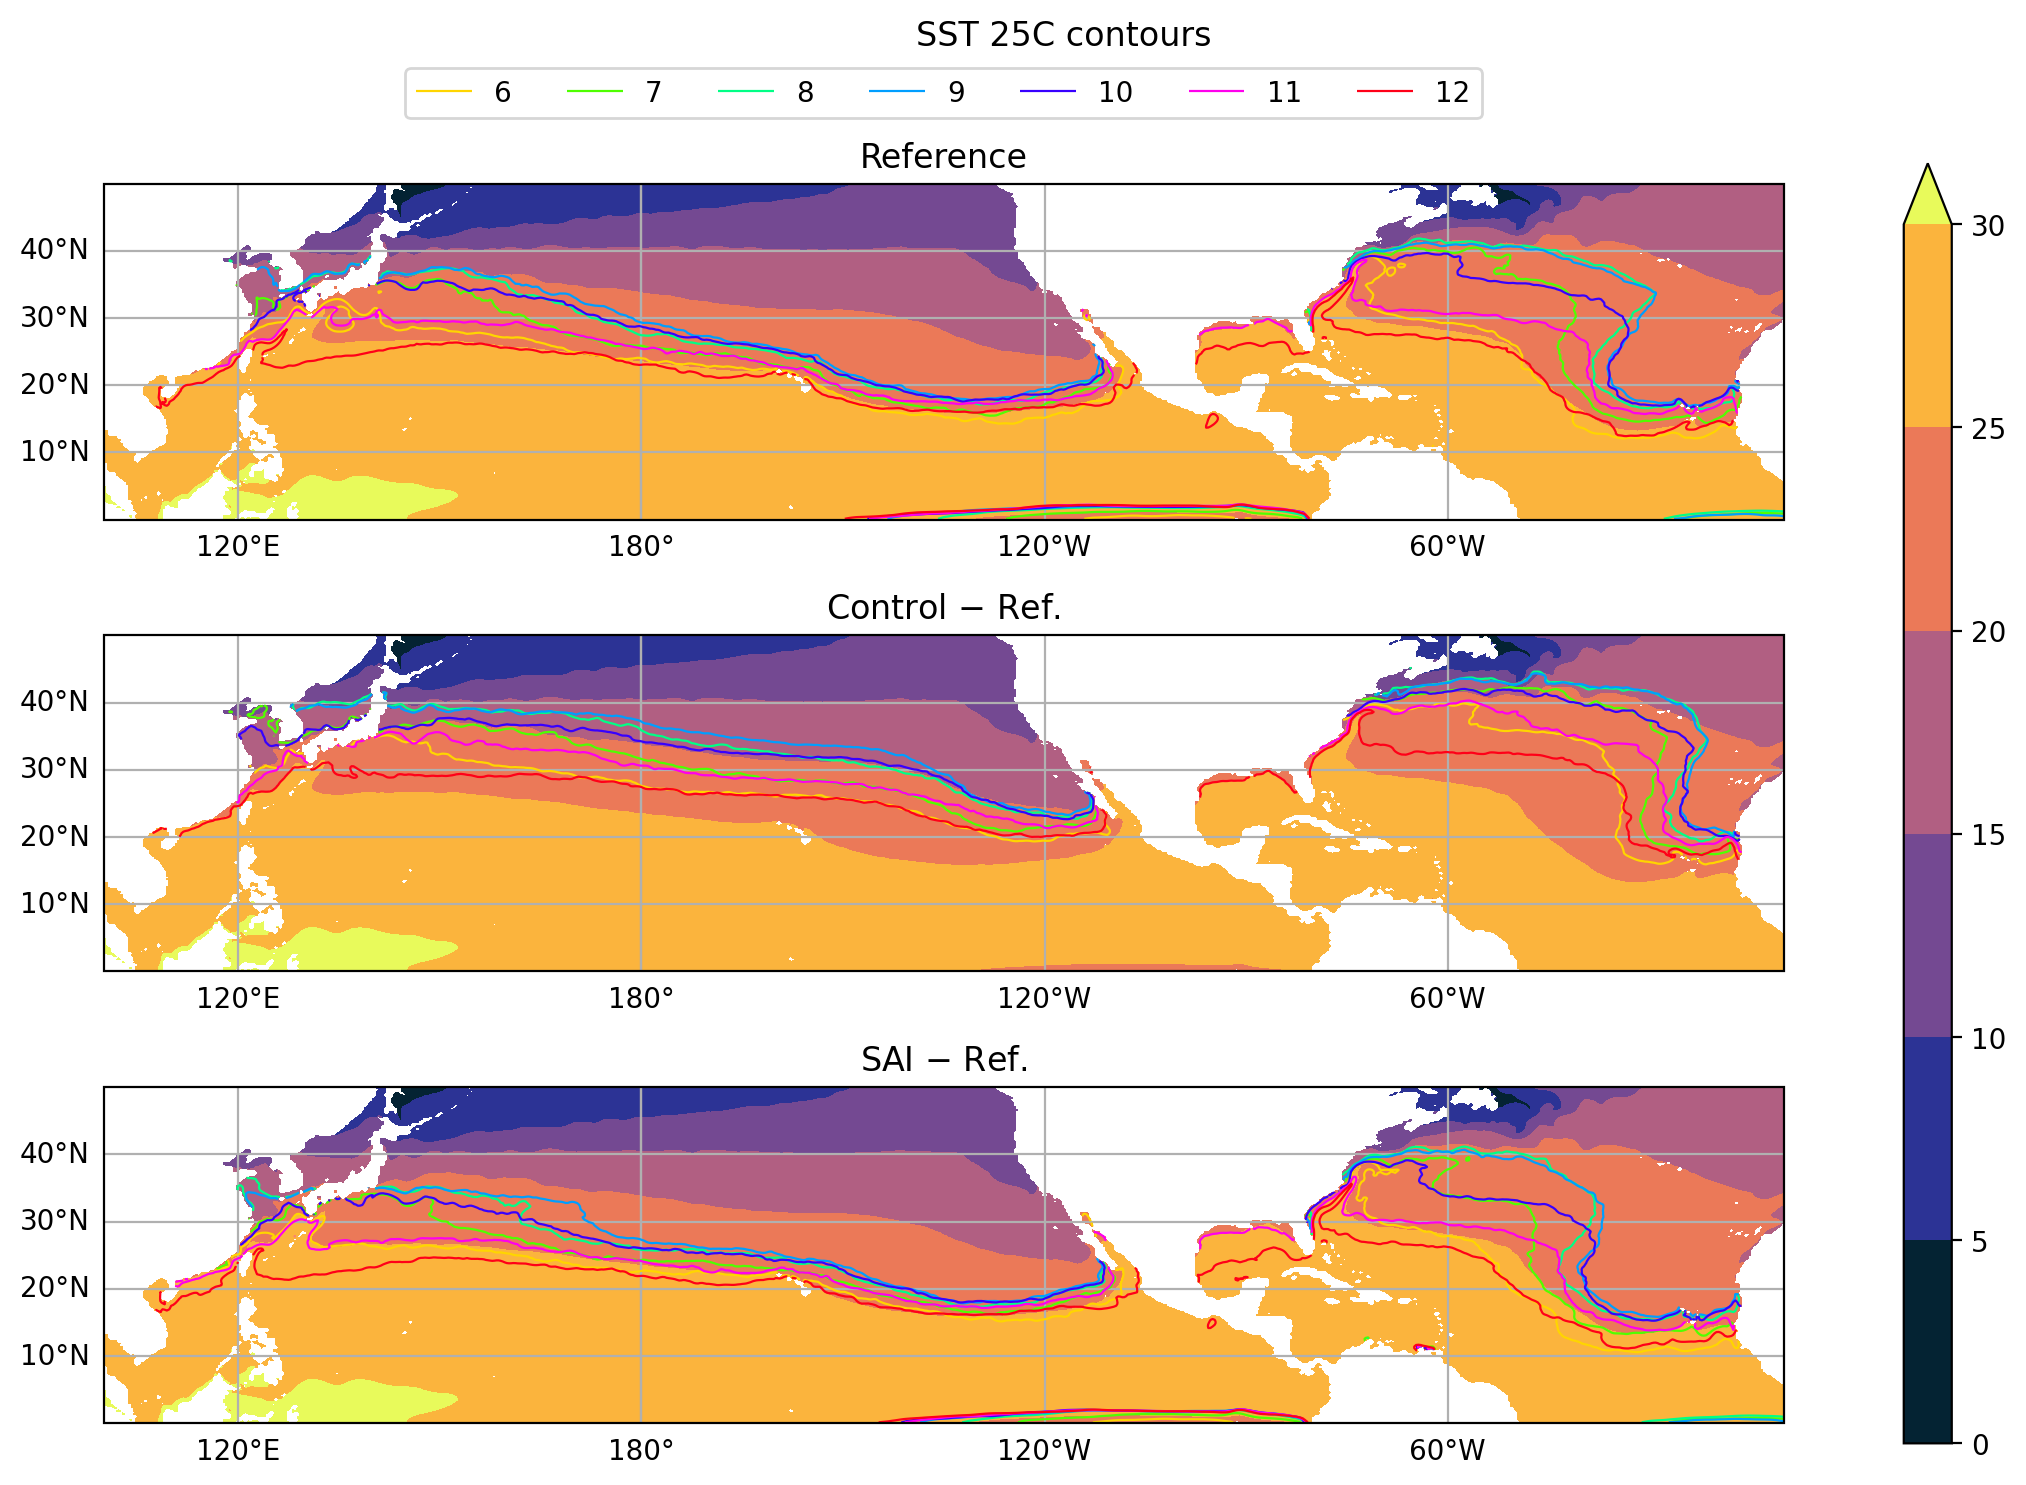

In [63]:
fig,axs = plt.subplots(3,1, figsize=(12,8), sharex=True, sharey=True, dpi=200,subplot_kw={'projection':ccrs.PlateCarree(central_longitude=200)})

months = [3,4,5,6,7,8,9,10,11,12,1,2]
months = [6,7,8,9,10,11,12]
legend_elems = []
for ax,exp,tit in zip(axs, ['ref','cnt','sai'],['Reference','Control $-$ Ref.','SAI $-$ Ref.']):
    cf = ds.SST.sel(exp='ref', lat=slice(0,50)).weighted(ds.dpm).mean('month').where(ds.mask<0.1).plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cmap='cmo.thermal', add_colorbar=False, levels=range(0,31,5))
    ax.gridlines(draw_labels=['left','bottom'])
    for m,month in enumerate(months):
        cs = ds.SST.sel(exp=exp,month=month,lat=slice(0,50)).where(ds.mask<0.1).plot.contour(ax=ax, transform=ccrs.PlateCarree(), levels=[25], linewidths=[0.8], colors=[plt.get_cmap('hsv')((m+1)/len(months))])
        legend_elems.append(cs.legend_elements()[0][0])
    ax.set_extent((100,350,0,50), crs=ccrs.PlateCarree())
    ax.set_title(tit)

plt.subplots_adjust(0.1,0.1,0.8,0.9)
cbax = fig.add_axes((0.85,0.1,0.02,0.8))
fig.colorbar(cf, cax=cbax, shrink=0.5)

fig.legend(legend_elems, months, ncol=12, loc=(0.2,0.92))
fig.suptitle('SST 25C contours',y=0.99, ha='center')
fig.savefig('../figures/SST.25C.monmean.NH.pdf', bbox_inches='tight', transparent=True)

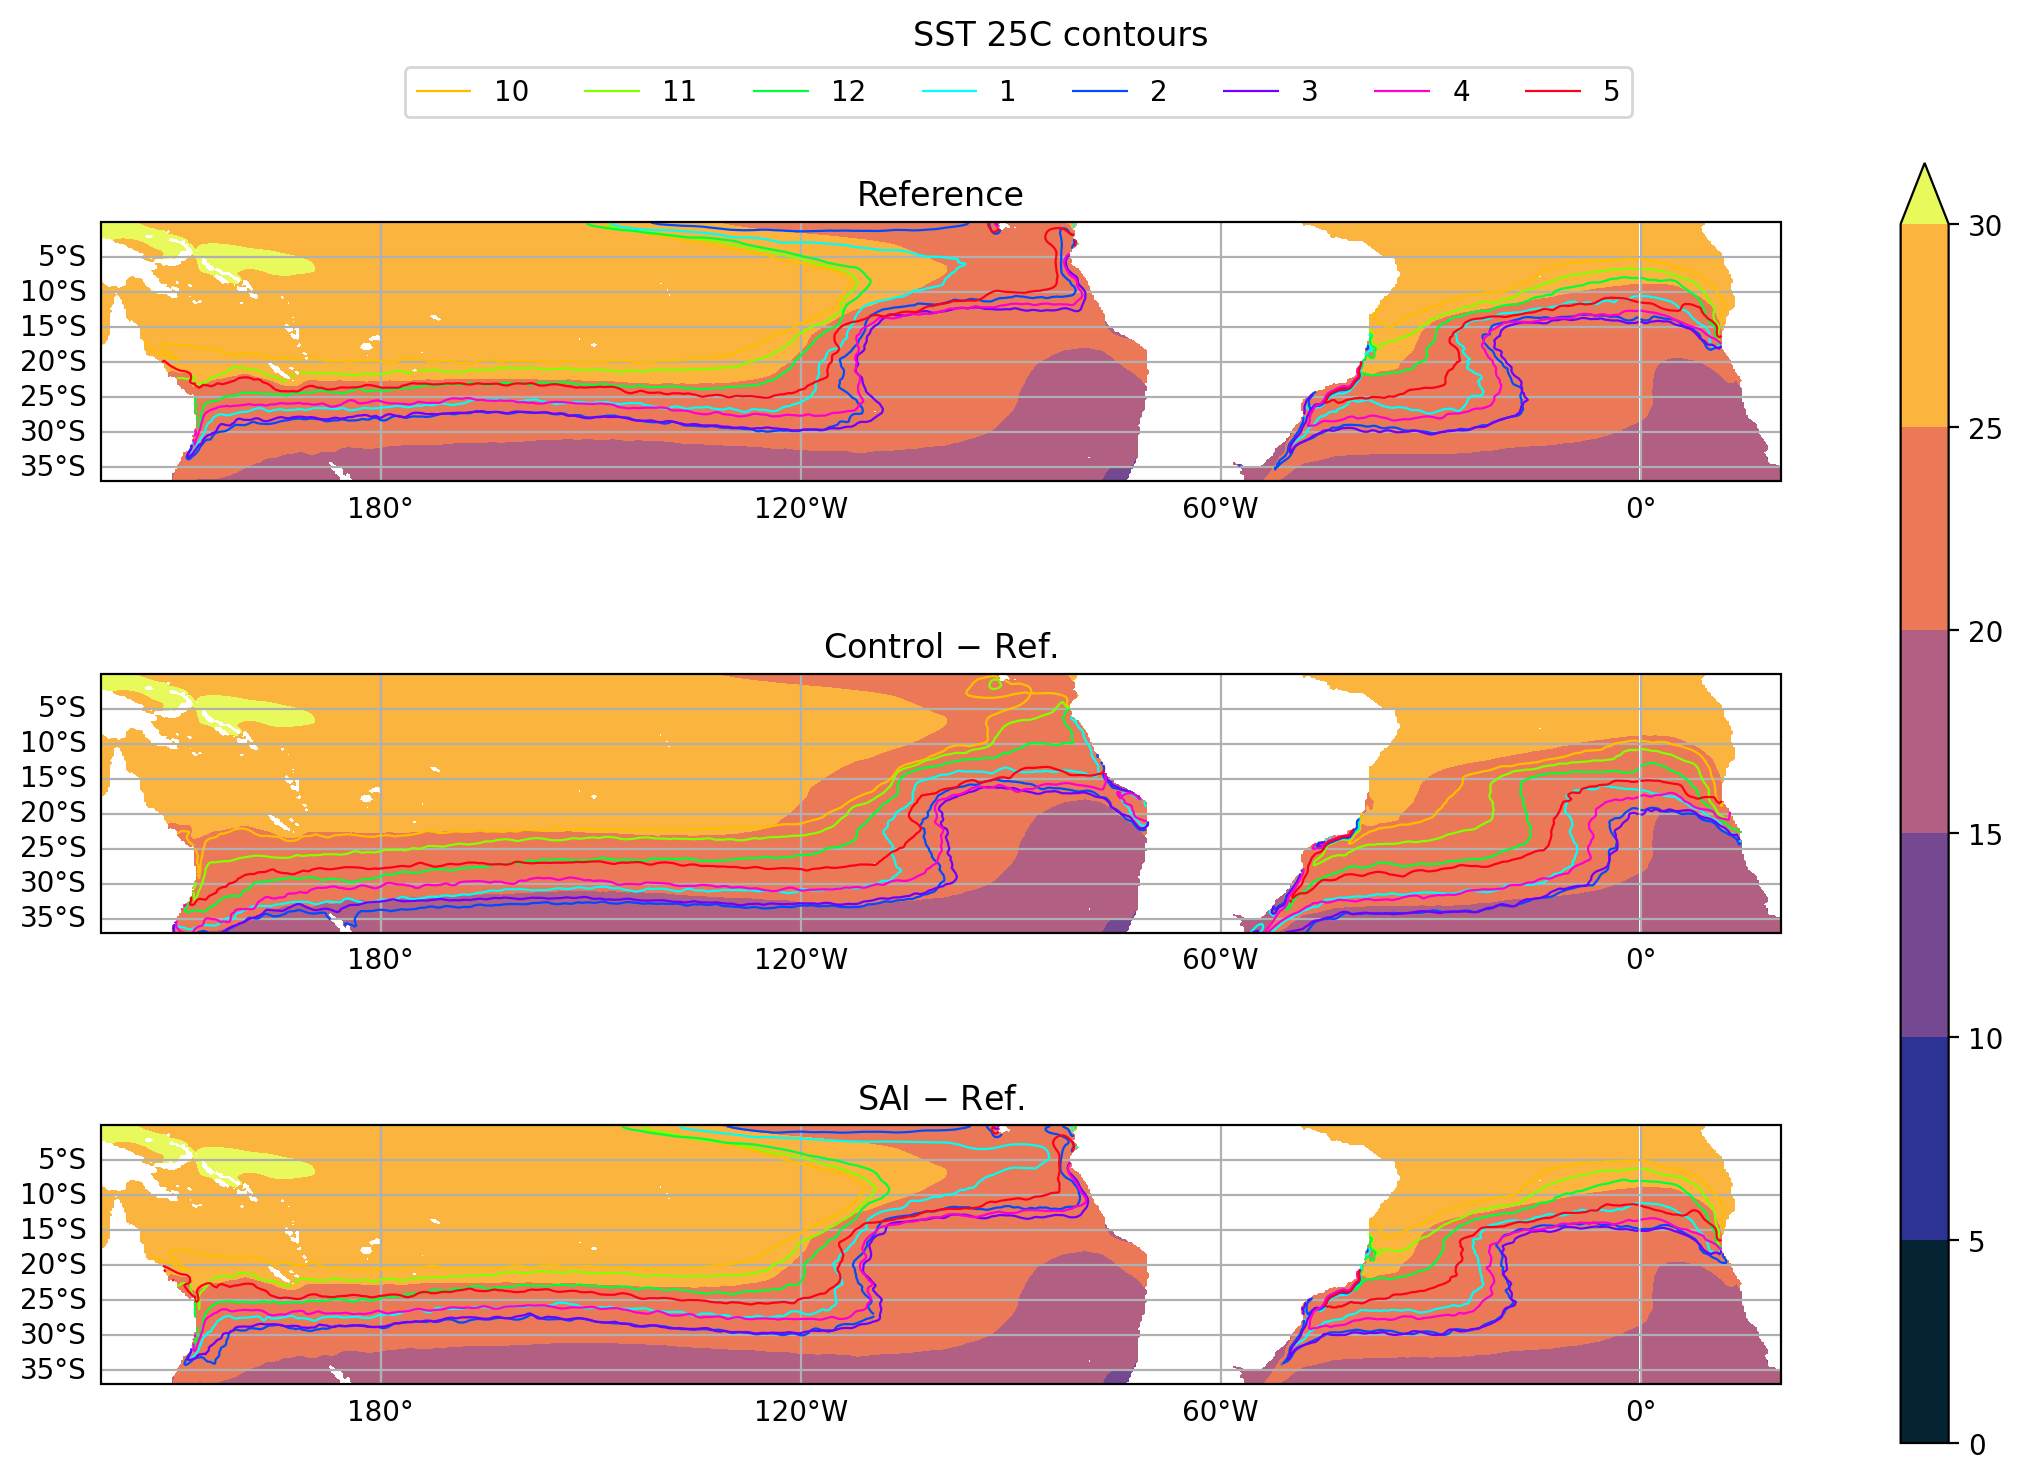

In [77]:
fig,axs = plt.subplots(3,1, figsize=(12,8), sharex=True, sharey=True, dpi=200,subplot_kw={'projection':ccrs.PlateCarree(central_longitude=300)})

months = [3,4,5,6,7,8,9,10,11,12,1,2]
months = [10,11,12,1,2,3,4,5]
legend_elems = []
for ax,exp,tit in zip(axs, ['ref','cnt','sai'],['Reference','Control $-$ Ref.','SAI $-$ Ref.']):
    cf = ds.SST.sel(exp='ref', lat=slice(-40,0)).weighted(ds.dpm).mean('month').where(ds.mask<0.1).plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cmap='cmo.thermal', add_colorbar=False, levels=range(0,31,5))
    ax.gridlines(draw_labels=['left','bottom'])
    for m,month in enumerate(months):
        cs = ds.SST.sel(exp=exp,month=month,lat=slice(-40,0)).where(ds.mask<0.1).plot.contour(ax=ax, transform=ccrs.PlateCarree(), levels=[25], linewidths=[0.8], colors=[plt.get_cmap('hsv')((m+1)/len(months))])
        legend_elems.append(cs.legend_elements()[0][0])
    ax.set_extent((140,380,-37,0), crs=ccrs.PlateCarree())
    ax.set_title(tit)

plt.subplots_adjust(0.1,0.1,0.8,0.9)
cbax = fig.add_axes((0.85,0.1,0.02,0.8))
fig.colorbar(cf, cax=cbax, shrink=0.5)

fig.legend(legend_elems, months, ncol=12, loc=(0.2,0.92))
fig.suptitle('SST 25C contours',y=0.99, ha='center')
fig.savefig('../figures/SST.25C.monmean.SH.pdf', bbox_inches='tight', transparent=True)